# T39 — Deep-time paleoclimate model snapshots on reconstructed coastlines

**Render an annual-mean surface-air-temperature (SAT) field from a deep-time paleoclimate model on top of reconstructed paleo-coastlines + plate-boundary backbone at the matching age. Default deep-time snapshot is the cGENIE-PLASIM end-Permian (252 Ma, 8960 ppm CO2) hothouse simulation (bundled with this tutorial collection); modern HadCM3 SAT is shown as the present-day reference. The anomaly cell regrids the deep-time field onto the modern grid for a direct deep-modern SAT difference.**

## What this notebook produces

Three figures:
1. A Mollweide map of the deep-time SAT (default: cGENIE-PLASIM 252 Ma end-Permian) with reconstructed paleo-coastlines + plate-boundary backbone overlaid in black/gray.
2. An anomaly map of deep-time SAT minus modern HadCM3 SAT (deep-time field interpolated onto the modern grid before subtraction).
3. (Optionally extendable to other models / ages by swapping `PALEO_DEEP_NC` in the CONFIGURATION cell.)

Earlier versions of this notebook used the HadCM3 Pliocene snapshot at 3 Ma — but at 3 Ma the continents are essentially indistinguishable from modern, so the reconstructed-paleo-context overlay added no visual information. The end-Permian (252 Ma, full Pangaea, single ocean) is dramatically different and showcases the value of the reconstruction.

## Data availability

This notebook bundles two small annual-mean SAT fields:

- **Modern (HadCM3 pre-industrial control)** — `data/paleoclimate/hadcm3_modern_mat.nc`. Annual-mean 2-m surface air temperature, downsampled to a 72×96 lat/lon grid (~37 KB). Source: Valdes et al. (2017, 2021) HadCM3 PI control simulation.
- **Deep-time (cGENIE-PLASIM 252 Ma end-Permian, 8960 ppm CO2)** — `data/paleoclimate/cgenie_plasim_endpermian_252Ma_8960ppm_sat.nc`. Annual-mean surface-air-temperature field from the atmospheric component (PLASIM) of a SCION-driven cGENIE hothouse simulation; 32×64 native grid (~19 KB). 

To swap in a different deep-time model output:
1. Drop your NC at `data/paleoclimate/<your_file>.nc` with variable `SAT_C(lat, lon)` in degC, lat ascending, lon –180→180.
2. Change `PALEO_DEEP_NC`, `SNAPSHOT_AGE_MA`, `DEEP_MODEL_NAME`, and `DEEP_LABEL_SHORT` in the CONFIGURATION cell.
3. Re-run.

Useful sources to draw from include Bristol BRIDGE Valdes 2021 HadCM3L Phanerozoic runs (`https://www.paleo.bristol.ac.uk/ungated/scotese/`), the DeepMIP Eocene model ensemble, cGENIE configurations published with SCION, and the PALEOMAP climate maps paired with Scotese & Wright (2018) paleo-DEMs.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import os, numpy as np, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change snapshot age + variable + range here

In [2]:
# === USER CONFIGURATION =====================================================
# T39 shows two paleoclimate model snapshots side-by-side:
#   * MODERN — HadCM3 annual-mean SAT (pre-industrial control)
#   * DEEP TIME — cGENIE-PLASIM 252 Ma end-Permian SAT at 8960 ppm CO2
#     ((bundled with this tutorial collection)).
# The plate model + reconstruction time apply to the DEEP-TIME snapshot only;
# the modern snapshot is shown at present-day coordinates as the reference state.
MODEL_NAME       = "Zahirovic2022"
ANCHOR_PLATE_ID  = 701701   # Z22 paleomag-frame anchor (cluster-I approved)
HADCM3_MOD_NC    = "data/paleoclimate/hadcm3_modern_mat.nc"
PALEO_DEEP_NC    = "data/paleoclimate/cgenie_plasim_endpermian_252Ma_8960ppm_sat.nc"
DEEP_LABEL_SHORT = "end-Permian (252 Ma, 8960 ppm CO2)"
DEEP_MODEL_NAME  = "cGENIE-PLASIM"
SNAPSHOT_AGE_MA  = 252.0
TEMP_PALETTE     = "polar"         # diverging blue→white→red — used by BOTH modern and deep-time maps
TEMP_PALETTE_REV = False            # polar default IS blue=cold, red=hot
TEMP_RANGE_C     = (0, 60, 2)      # DEEP-TIME (end-Permian) clamp: brackets 2.84 → 56.24 degC
MODERN_RANGE_C   = (-30, 30, 2)    # MODERN HadCM3 PI control clamp: brackets ~-13 → +30 degC,
                                    # symmetric around 0 degC so polar regions (cold blue) and
                                    # tropics (warm red) both have full dynamic range.
ANOM_RANGE_C     = (-37, 37, 1)    # symmetric around 0; jet palette saturates at ±37
# ============================================================================

## 1. Load both snapshots — modern HadCM3 + deep-time cGENIE-PLASIM

In [3]:
# Cell 2 — load both snapshots
deep = xr.open_dataarray(PALEO_DEEP_NC)
mod  = xr.open_dataarray(HADCM3_MOD_NC)
print(f"DEEP ({DEEP_LABEL_SHORT}, {DEEP_MODEL_NAME}): "
      f"shape={deep.shape}, range=[{float(deep.min()):.1f}, {float(deep.max()):.1f}] degC")
print(f"MODERN (HadCM3 PI control): "
      f"shape={mod.shape}, range=[{float(mod.min()):.1f}, {float(mod.max()):.1f}] degC")

DEEP (end-Permian (252 Ma, 8960 ppm CO2), cGENIE-PLASIM): shape=(32, 64), range=[2.8, 56.2] degC
MODERN (HadCM3 PI control): shape=(72, 96), range=[-13.0, 30.0] degC


## 2. Plate-model setup (shared by all rendering cells below)

In [4]:
# Cell 1a — build the plate reconstruction once; all map-render cells use it
pmm    = PlateModelManager()
model  = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon  = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

print(f"  plate model: {MODEL_NAME} (anchor {ANCHOR_PLATE_ID})")

  plate model: Zahirovic2022 (anchor 701701)


## 3. Modern HadCM3 SAT (present-day reference state)

Rendered first as a visual reference, so the deep-time panel and the deep–modern anomaly panel further down are interpreted against a familiar present-day climate. Uses the same polar palette + 0-60 degC clamp as the deep-time map for direct side-by-side comparison; modern polar SAT (~−13 degC at lowest) saturates at the deep-blue cpt bottom.

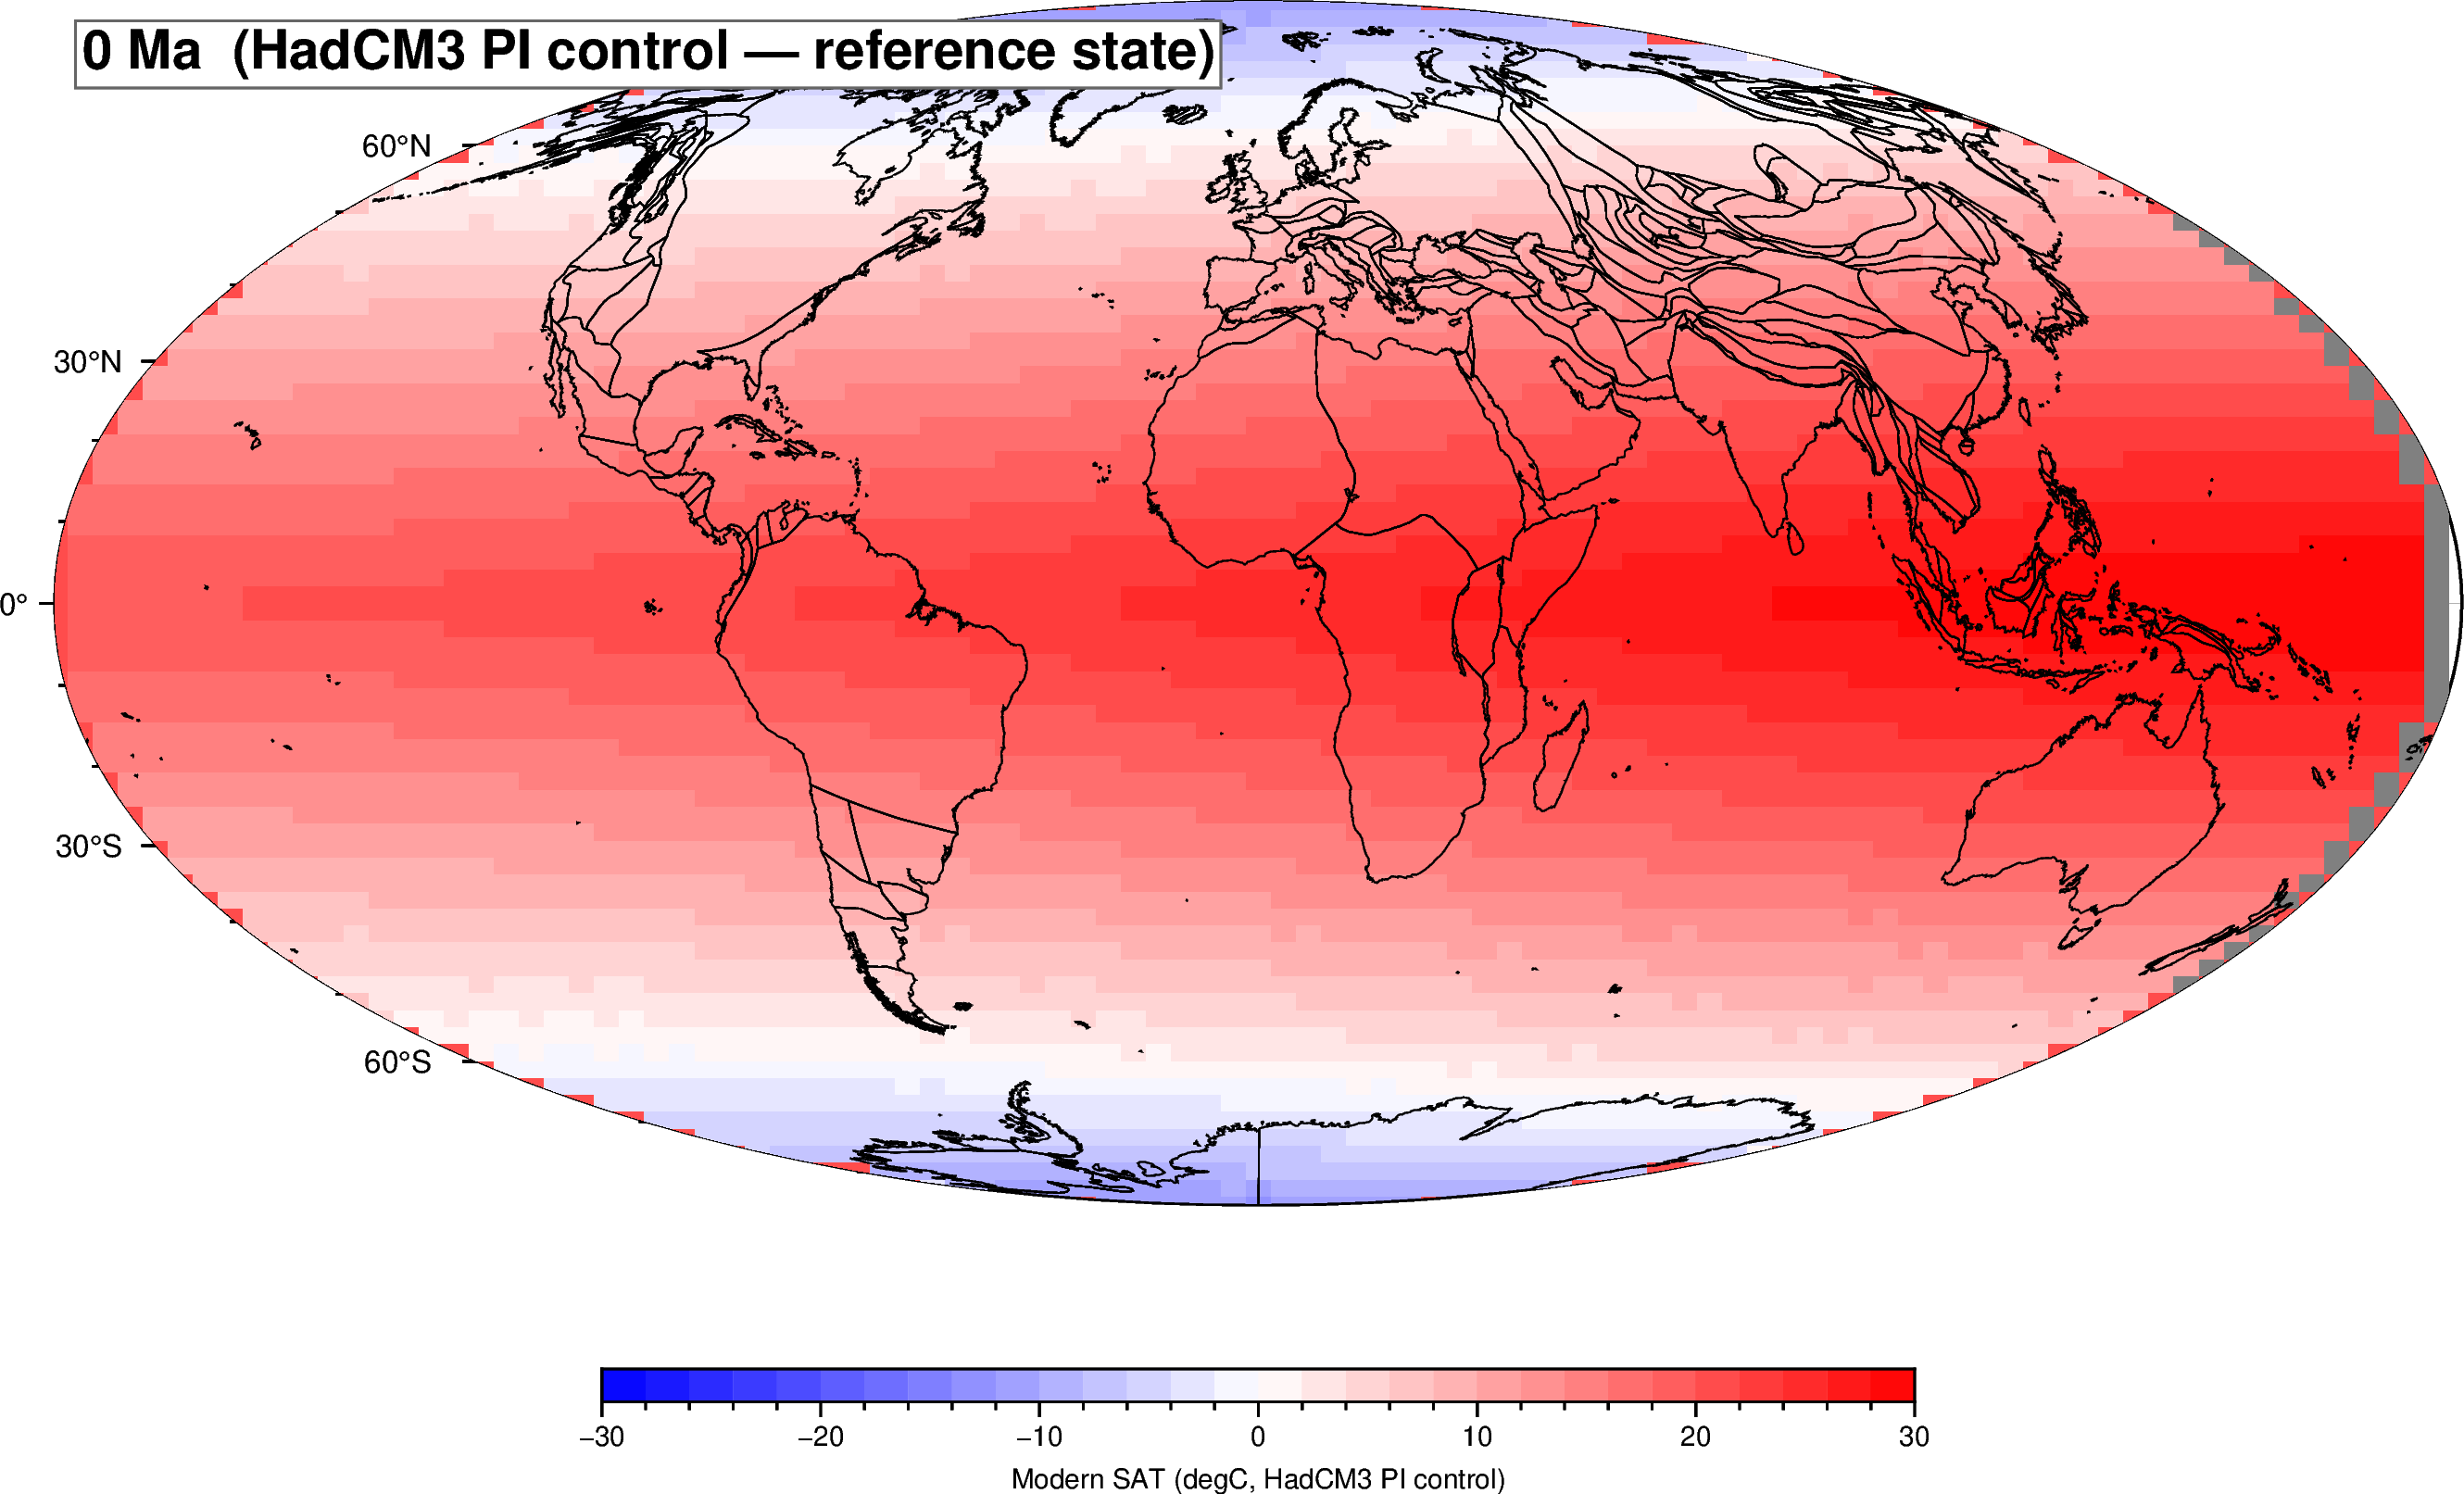

In [5]:
# Cell 2a — modern HadCM3 SAT (reference)
gplot_mod = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=0.0,

plot_engine=gplately.PygmtPlotEngine(),
)

fig = pygmt.Figure()
pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70")
fig.basemap(region="d", projection="W0/22c", frame=["af", "yg20"])
pygmt.makecpt(cmap=TEMP_PALETTE, series=list(MODERN_RANGE_C),
              reverse=TEMP_PALETTE_REV)
fig.grdimage(mod, cmap=True)
fig.colorbar(frame="af+lModern SAT (degC, HadCM3 PI control)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
try:
    gplot_mod.plot_coastlines(fig, pen="0.4p,black")
except Exception:
    pass
fig.text(text="0 Ma  (HadCM3 PI control — reference state)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## 4. Deep-time SAT field with reconstructed paleo-coastlines

grdinfo [WARNING]: The step size of coordinate (lat) in grid /Users/dietmar/Documents/GPlates/GPlately-pyGMT_tutorials/data/paleoclimate/cgenie_plasim_endpermian_252Ma_8960ppm_sat.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of 5.53294; the original ranges from 5.49181 to 5.53781.
grdinfo [WARNING]: Guessing of registration in conflict between x and y, using gridline
/opt/miniconda3/lib/python3.12/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'lat' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5329413414001465 is assumed in the 'lat' dimension.


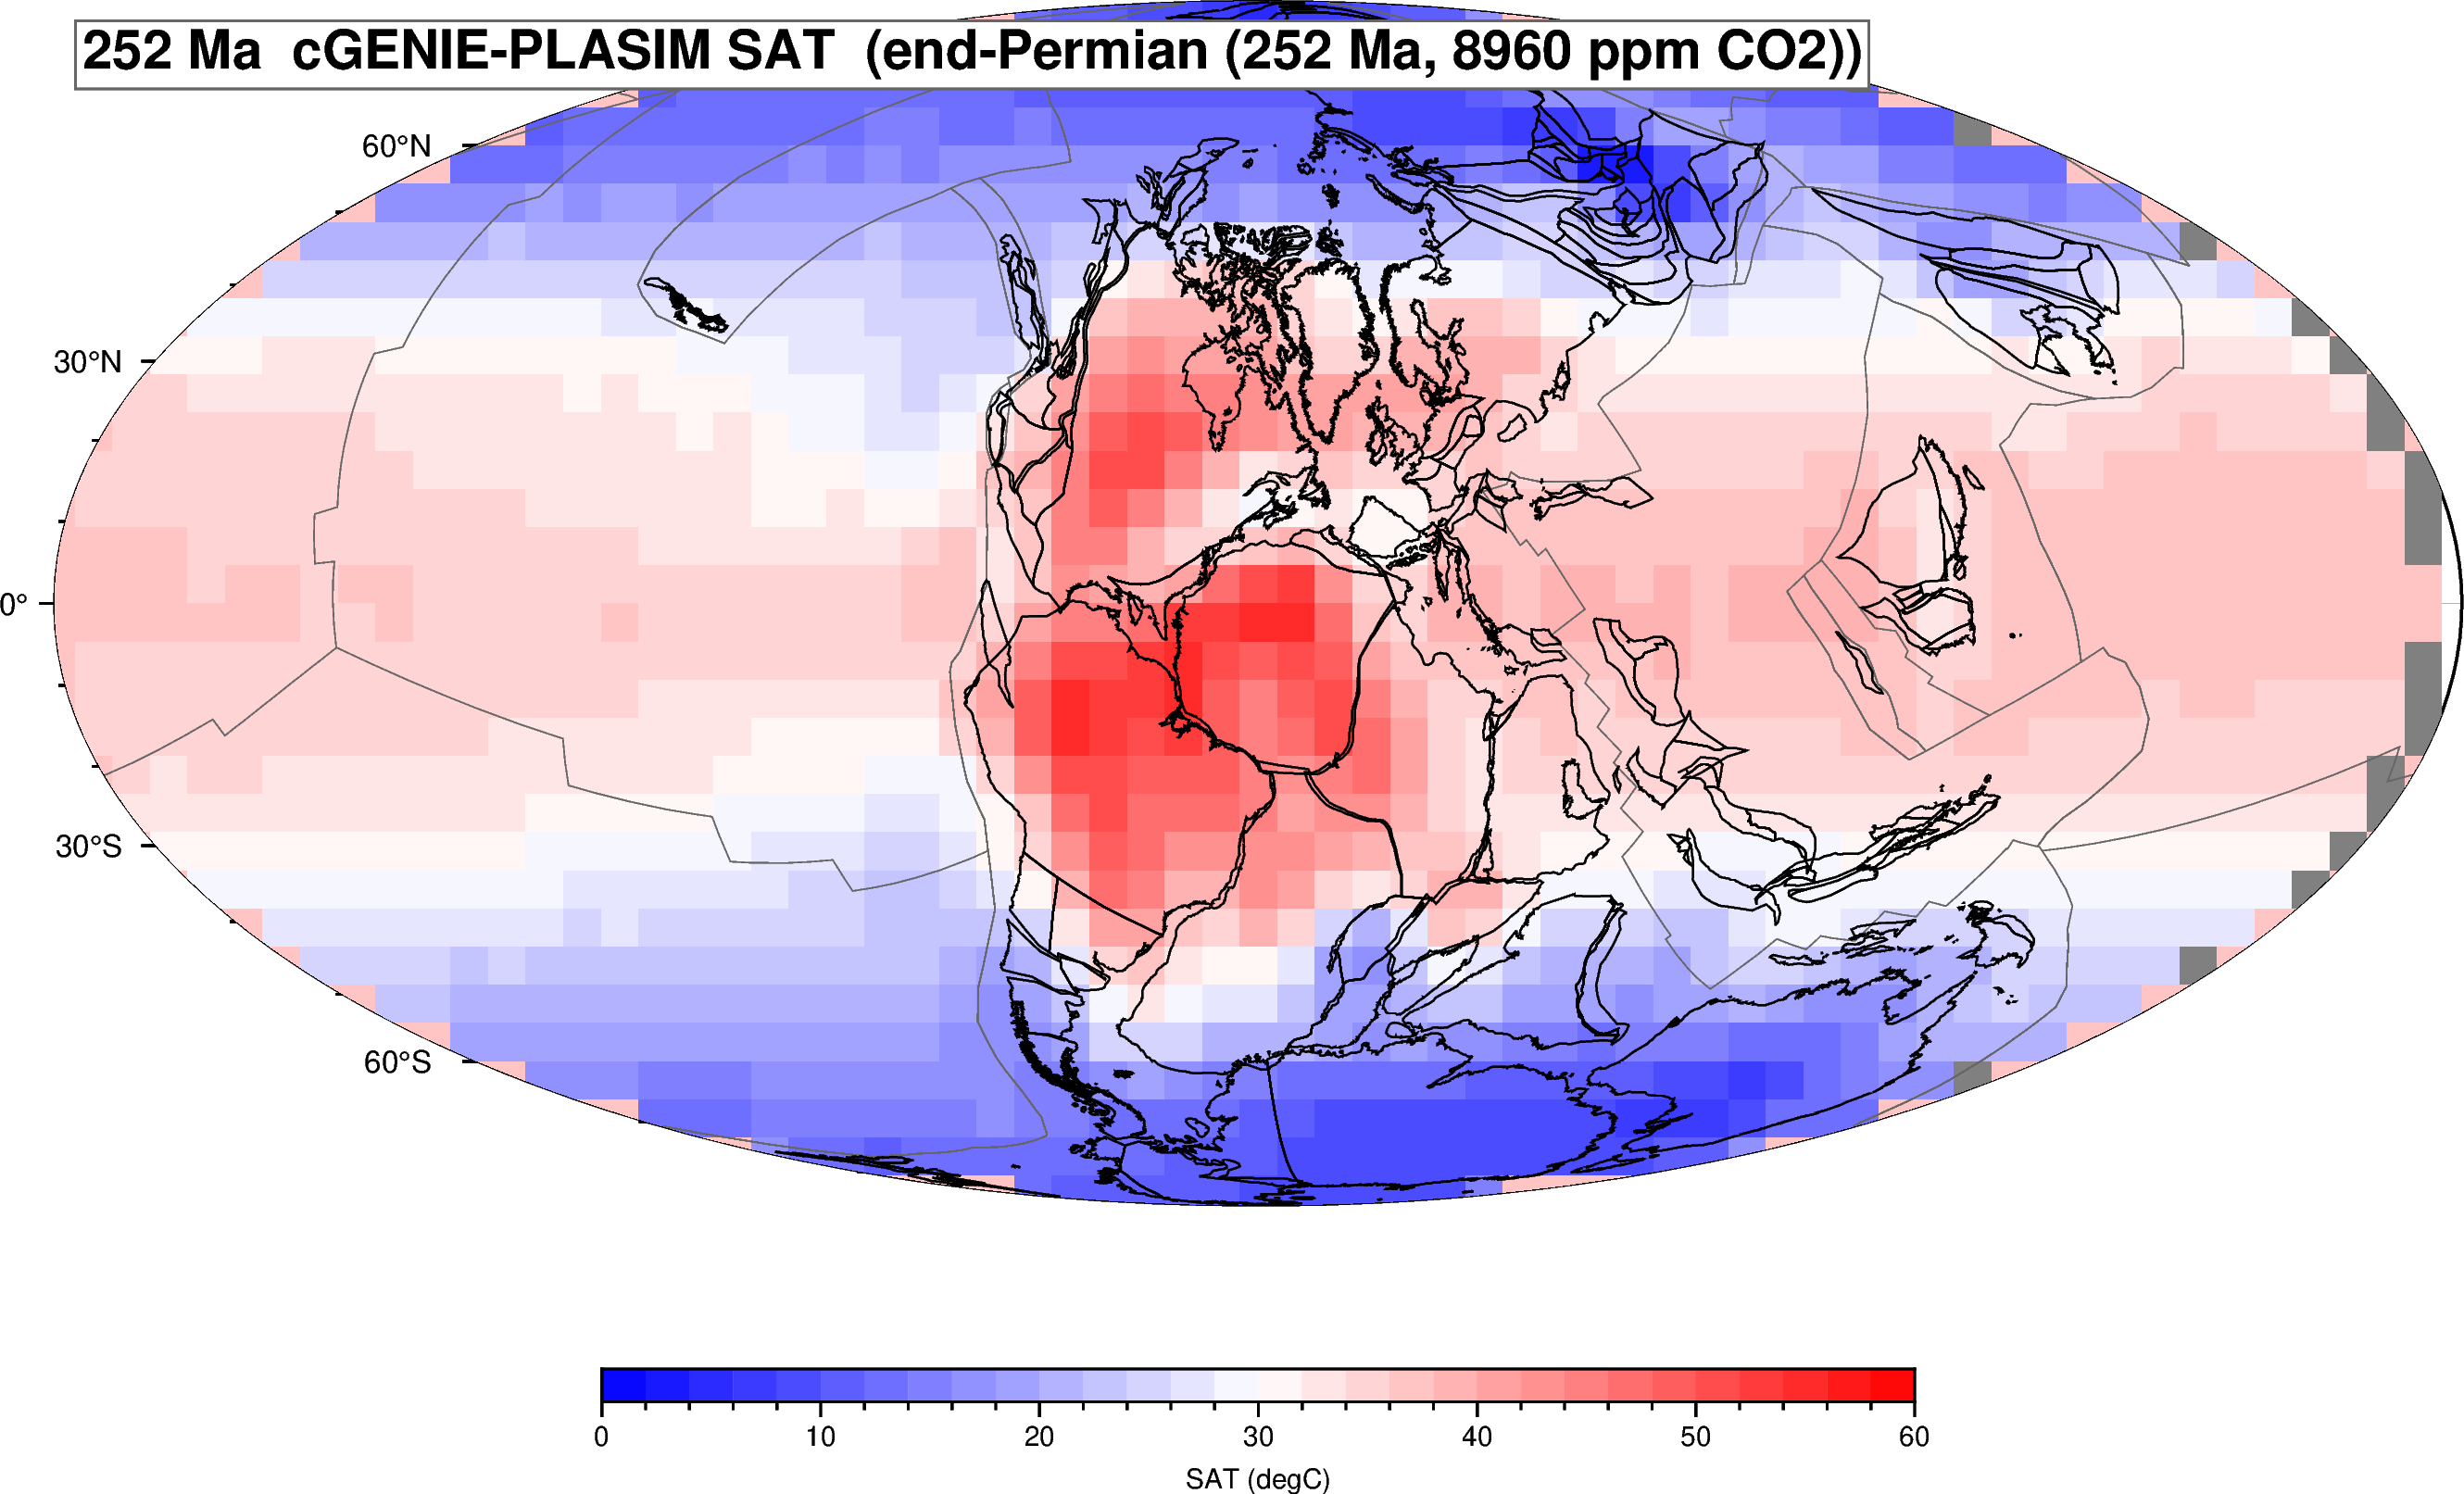

In [6]:
# Cell 3 — deep-time snapshot with reconstructed coastlines + plate-boundary backbone
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_coastlines(),
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(SNAPSHOT_AGE_MA),

plot_engine=gplately.PygmtPlotEngine(),
)

fig = pygmt.Figure()
pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70")
fig.basemap(region="d", projection="W0/22c", frame=["af", "yg20"])
pygmt.makecpt(cmap=TEMP_PALETTE, series=list(TEMP_RANGE_C),
              reverse=TEMP_PALETTE_REV)
fig.grdimage(deep, cmap=True)
fig.colorbar(frame="af+lSAT (degC)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
# Reconstructed plate-boundary backbone (continuous-backbone pattern)
try:
    gplot.plot_all_topological_sections(fig, pen="0.3p,gray40")
except Exception:
    pass
# Reconstructed paleo-coastlines as thin black lines
try:
    gplot.plot_coastlines(fig, pen="0.5p,black")
except Exception:
    pass
fig.text(text=f"{SNAPSHOT_AGE_MA:.0f} Ma  {DEEP_MODEL_NAME} SAT  ({DEEP_LABEL_SHORT})",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="14p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)
display(HTML('<div style="height:1cm"></div>'))

## 5. Anomaly map: deep-time SAT − modern SAT

  anomaly range: [-1.2, 36.2] degC
  plotted range (clipped): [-1.2, 36.2] degC


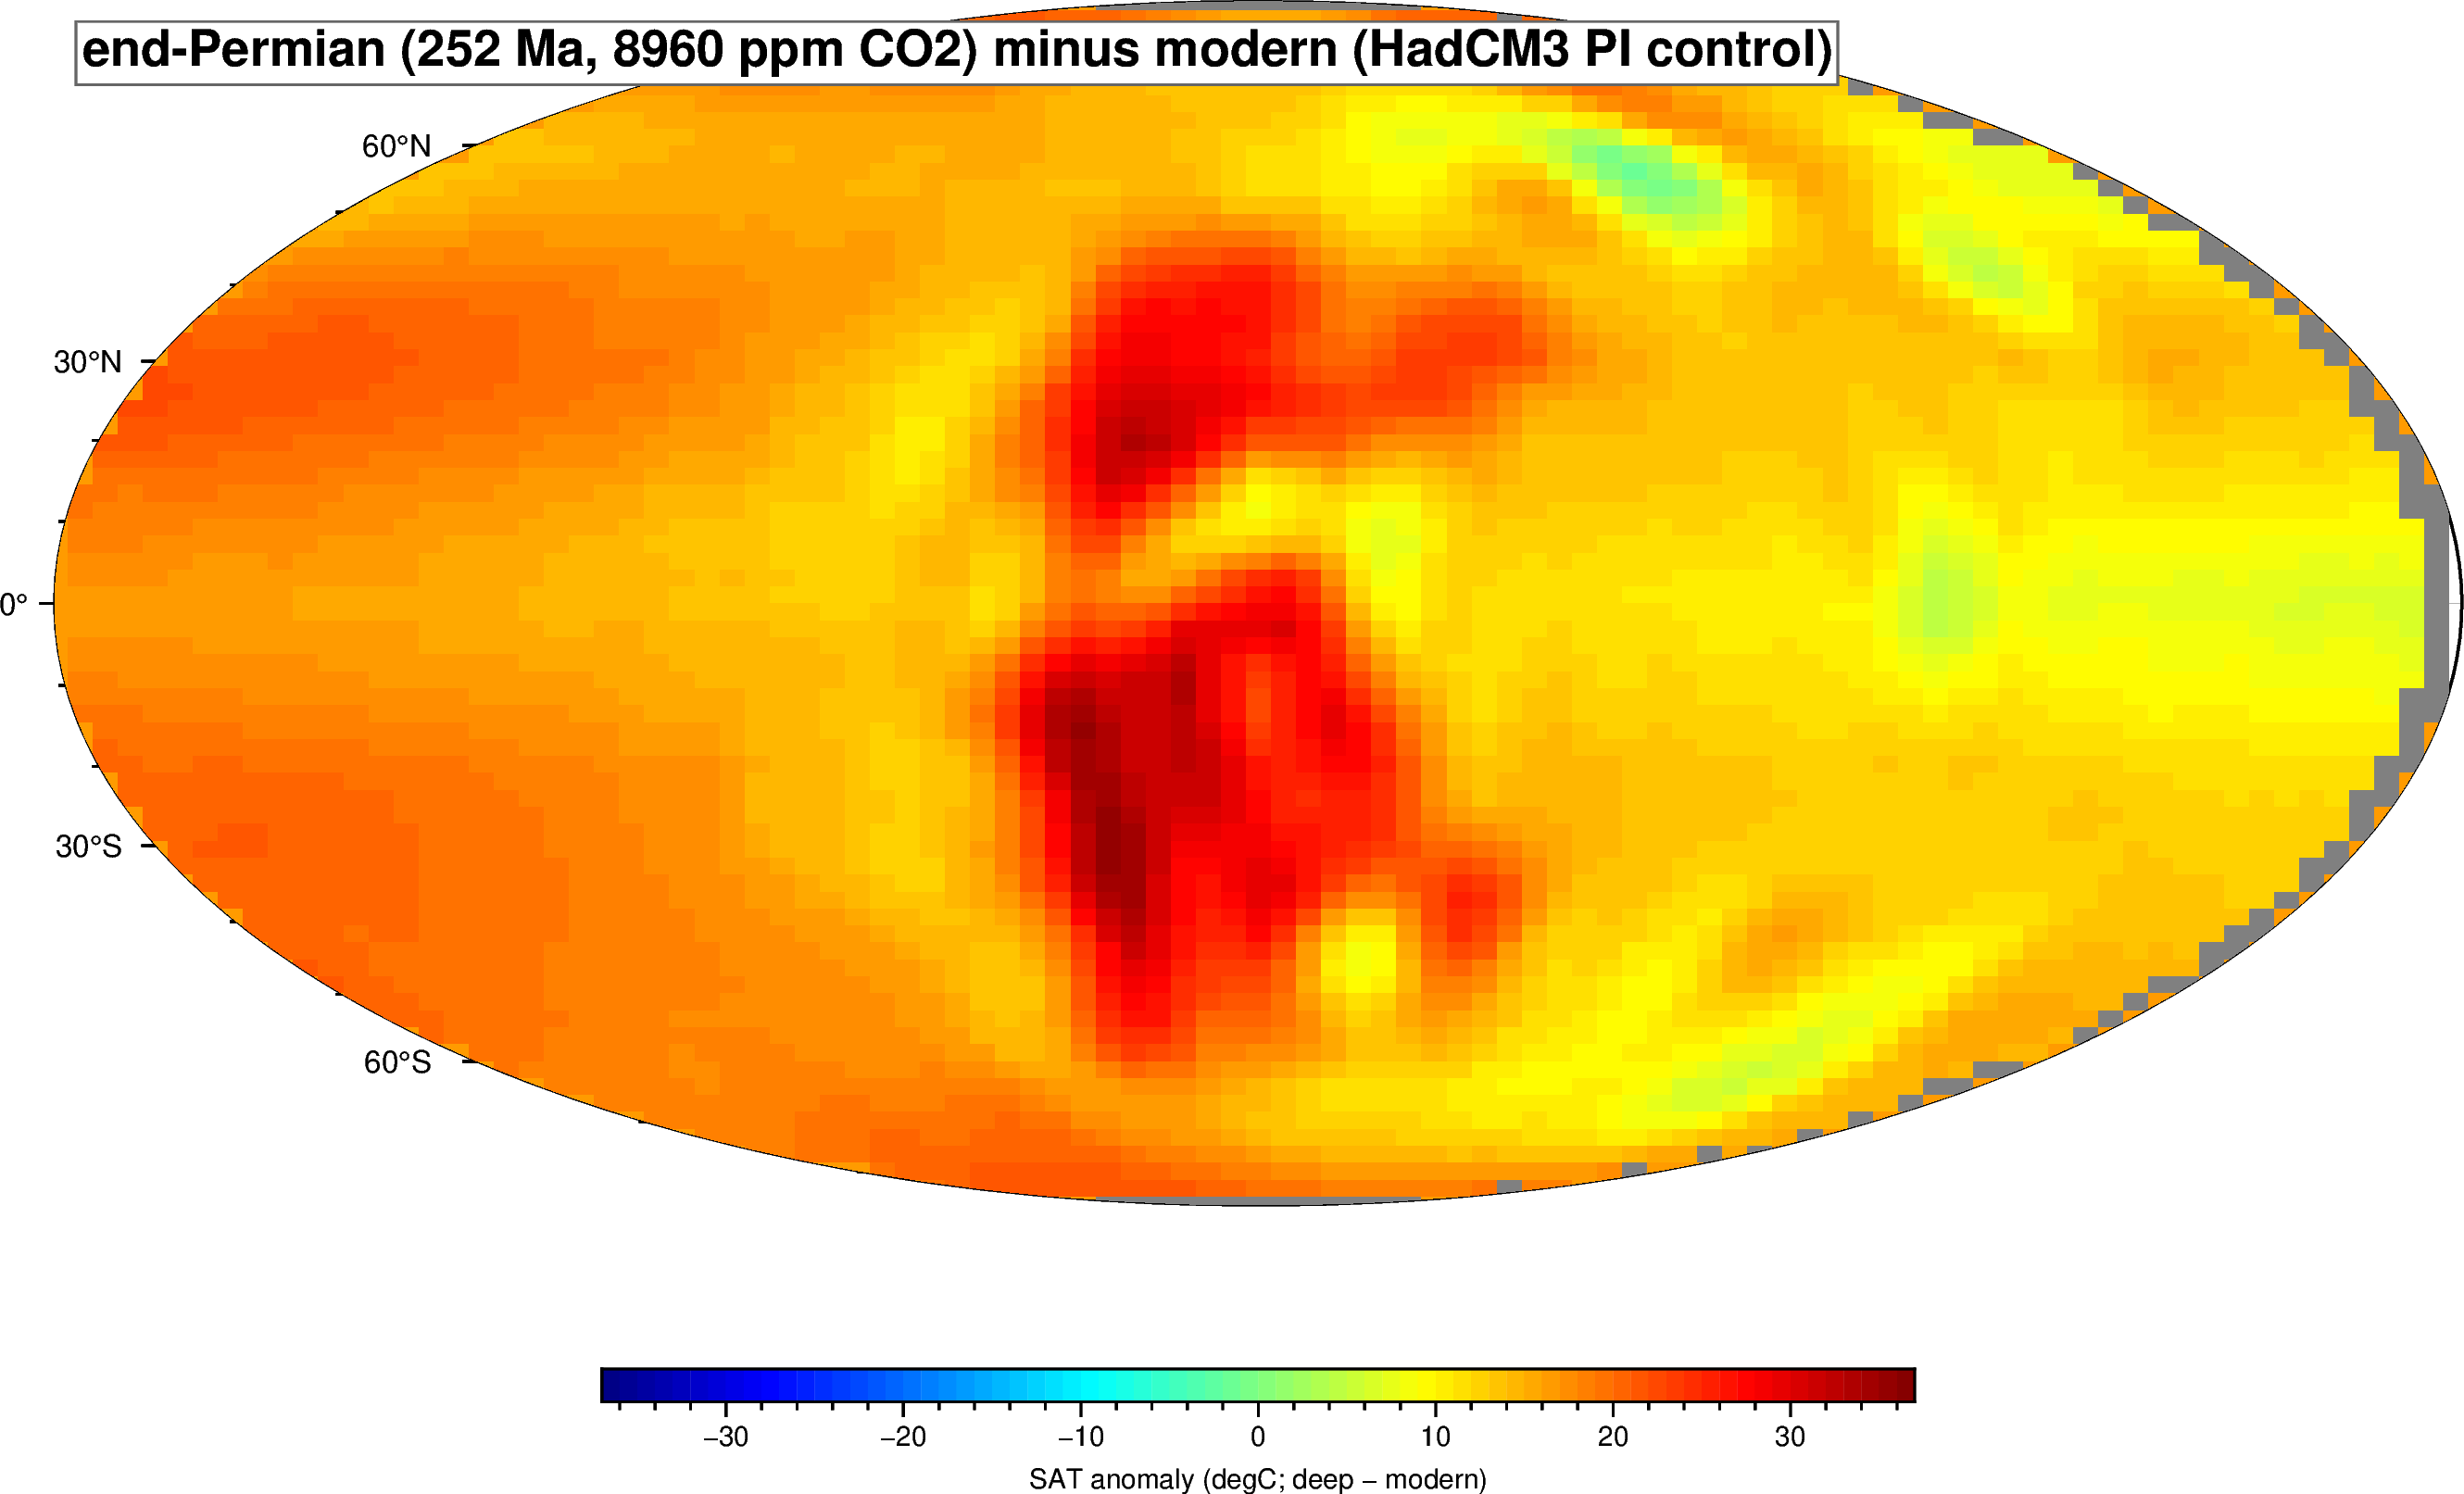

In [7]:
# Cell 4 — anomaly: deep-time SAT − modern SAT (deep-time regridded to modern grid)
# The two snapshots live on different model grids (PLASIM 32×64 vs HadCM3 72×96).
# Interpolate deep-time onto the modern grid before subtraction.
deep_on_mod = deep.interp(lat=mod.lat, lon=mod.lon, method="linear")
anom = deep_on_mod - mod
print(f"  anomaly range: [{float(anom.min()):.1f}, {float(anom.max()):.1f}] degC")
# Clip the data so values outside ANOM_RANGE_C paint with the extreme cpt
# colour (otherwise pyGMT/GMT may render them as transparent/blank).
anom_for_plot = anom.clip(min=ANOM_RANGE_C[0], max=ANOM_RANGE_C[1])
print(f"  plotted range (clipped): [{float(anom_for_plot.min()):.1f}, {float(anom_for_plot.max()):.1f}] degC")

fig = pygmt.Figure()
pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70")
fig.basemap(region="d", projection="W0/22c", frame=["af", "yg20"])
pygmt.makecpt(cmap="jet", series=list(ANOM_RANGE_C))  # symmetric jet for anomaly
fig.grdimage(anom_for_plot, cmap=True)
fig.colorbar(frame="af+lSAT anomaly (degC; deep − modern)",
             position="JBC+w12c/0.3c+h+o0/1.5c")
fig.text(text=f"{DEEP_LABEL_SHORT} minus modern (HadCM3 PI control)",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="13p,Helvetica-Bold,black",
         fill="white", pen="0.6p,gray40")
fig.show(width=1100)

## What the figures show

This notebook produces three Mollweide maps in sequence:

1. **Modern HadCM3 SAT (cell 2a)** — annual-mean 2-m surface air temperature from a HadCM3 pre-industrial control simulation, painted with the `polar` palette stretched 0 → 60 °C. Modern polar cells (~−13 °C at lowest) saturate at the deep-blue cpt bottom; modern coastlines drawn in 0.5p black via `gplately.PlotTopologies(time=0)`. This panel is the present-day reference.

2. **Deep-time SAT (cell 3)** — the bundled cGENIE-PLASIM end-Permian (252 Ma, 8960 ppm CO₂) hothouse simulation, on the SAME `polar` 0 → 60 °C palette so the deep-time field is directly comparable to the modern panel above. Reconstructed paleo-coastlines + plate-boundary backbone from the user-chosen `MODEL_NAME` (Zahirovic 2022 in the paleomag frame, `ANCHOR_PLATE_ID = 701701`) overlaid at the snapshot age. Equatorial peaks reach ~56 °C; polar SAT sits near +2 to +5 °C — no continental glaciation anywhere, the signature of a deep-time hothouse driven by 8960 ppm CO₂ (~32× modern).

3. **Anomaly map: deep-time SAT − modern SAT (cell 4)** — the deep-time field is interpolated onto the modern HadCM3 grid (`xarray.interp(method="linear")`) so the two can be subtracted cell-by-cell. Rendered with the symmetric `jet` palette clamped at ±30 °C; cells outside that range are clipped numerically before plotting so they paint with the cpt extreme colours (red = strong warming, dark blue = strong cooling) rather than dropping out as transparent. Look for:
   - **Tropical hotspots** of +20–30 °C warming over the Pangaean interior where the hothouse CO₂ drives intense continental heating.
   - **Polar amplification** of similar magnitude — high latitudes warm a comparable amount because the modern poles are far below freezing while the end-Permian poles are above zero.
   - **Negligible cooling regions** — the 252 Ma simulation is uniformly warmer than modern, so blue patches are mostly absent. Any small negative anomalies typically reflect the deep-time tropical-to-subtropical ocean state where modern values are also near the upper end of the palette.

These three maps together demonstrate the *deep-time paleoclimate-model snapshot + reconstruction* workflow: take a climate-model SAT field, render it on its own grid, then re-project onto reconstructed paleo-coastlines from a plate model at the matching age, and difference it against modern to expose the climate-change signal.

## Extend this

- **Other deep-time snapshots.** Drop any NC at `data/paleoclimate/<your_file>.nc` with variable `SAT_C(lat, lon)` in degC, lat ascending, lon −180→180, and re-point `PALEO_DEEP_NC` + `SNAPSHOT_AGE_MA` + `DEEP_MODEL_NAME` + `DEEP_LABEL_SHORT` in the CONFIGURATION cell. Suggested sources:
  - **Bristol BRIDGE Valdes 2021 HadCM3L Phanerozoic ensemble** (`https://www.paleo.bristol.ac.uk/ungated/scotese/`) — ~110 paleoclimate snapshots from 540 Ma to present at ~5 Myr cadence.
  - **DeepMIP Eocene model ensemble** (Lunt et al. 2017) — well-sampled mid-Eocene (~50 Ma) climate-state ensemble across CO₂ levels.
  - **PaleoClim** (Brown et al. 2018) — bundles LGM, Last Interglacial, mid-Holocene HadCM3 snapshots for the Quaternary if you want a younger comparator.
  - **PALEOMAP climate maps** paired with Scotese & Wright (2018) paleo-DEMs.
- **Combine with T38.** Drop the Boucot et al. (2013) climate-sensitive lithology points (T38) for the same snapshot age on top of the deep-time SAT field. Are the coals + bauxites consistently in modelled warm/wet zones? Are the evaporites in modelled arid zones? Disagreements highlight either model bias or proxy mis-classification.
- **Cross-reference T40.** T40 does the same model-data comparison for **cGENIE SST** in the early Eocene with proxy SSTs overlaid; T39 does it for **SAT** at any age. The two together show two different climate variables + two different models in the same workflow.
- **Per-bin per-paleolatitude transect.** Sample the deep-time SAT along a zonal band (e.g. ±5° equatorial) and chart it longitudinally — useful for diagnosing zonal heat transport biases.
- **Symmetric vs asymmetric anomaly palette.** The `jet` ±30 °C anomaly is the default; the diverging Crameri palette `vik` would be a more scientifically-acceptable choice (perceptually uniform, CVD-safe). Swap `cmap="jet"` → `cmap="vik"` in cell 4 if you want a publication-grade anomaly map.

## References

- Boucot, A.J., Xu, C. & Scotese, C.R. (2013). *Phanerozoic Paleoclimate: An Atlas of Lithologic Indicators of Climate*. SEPM CSP 11. https://doi.org/10.2110/sepmcsp.11
- Brown, J.L. et al. (2018). PaleoClim. *Scientific Data* 5, 180254.
- Lunt, D.J., Farnsworth, A., Loptson, C., Foster, G.L., Markwick, P., O'Brien, C.L., Pancost, R.D., Robinson, S.A. & Wrobel, N. (2016). Palaeogeographic controls on climate and proxy interpretation. *Climate of the Past* 12, 1181–1198. https://doi.org/10.5194/cp-12-1181-2016
- **SCION (the method).** Mills, B.J.W., Donnadieu, Y. & Goddéris, Y. (2021). Spatial continuous integration of Phanerozoic global biogeochemistry and climate. *Gondwana Research* 100, 73–86. https://doi.org/10.1016/j.gr.2021.02.011
- **pySCION.** Merdith, A.S., Gernon, T.M., Maffre, P., Donnadieu, Y., Goddéris, Y., Longman, J., Müller, R.D. & Mills, B.J.W. (2025). Phanerozoic icehouse climates as the result of multiple solid-Earth cooling mechanisms. *Science Advances* 11(7), eadm9798. https://doi.org/10.1126/sciadv.adm9798 — Python implementation of SCION (uses SCION only; not cGENIE/PLASIM). (Python implementation of SCION with coupled climate-system components is the pipeline used to compute the bundled ensemble.)
- Valdes, P.J. et al. (2017). The BRIDGE HadCM3 family of climate models. *Geosci. Model Dev.* 10, 3715–3743.
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., et al. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., et al. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515